In [1]:
!pip install lightgbm shap pandas numpy scikit-learn matplotlib joblib

In [2]:
import pandas as pd
import numpy as np
np.random.seed(42)

def generate_gig_worker_data(n=5000):
    data = {}

    # Platform tenure (months active on gig platforms)
    data['platform_tenure_months'] = np.random.randint(1, 72, n)

    # Average monthly income ($500 - $8000)
    base_income = np.random.uniform(500, 8000, n)
    data['monthly_income_mean'] = base_income

    # Income volatility — high std = risky
    data['monthly_income_std'] = base_income * np.random.uniform(0.05, 0.60, n)

    # Income trend: positive = growing, negative = declining
    data['income_trend'] = np.random.uniform(-0.3, 0.3, n)

    # Number of active gig platforms (diversification = safer)
    data['active_platforms'] = np.random.randint(1, 6, n)

    # On-time bill payment rate (0.0 - 1.0)
    data['on_time_payment_rate'] = np.random.beta(8, 2, n)

    # Expense ratio (expenses / income) — over 0.9 is dangerous
    data['expense_ratio'] = np.random.beta(5, 3, n)

    # Debt-to-income ratio
    data['debt_to_income'] = np.random.uniform(0, 0.8, n)

    # Savings buffer (months of expenses saved)
    data['savings_buffer_months'] = np.random.exponential(2, n).clip(0, 12)

    # Total gig history in months
    data['total_gig_history_months'] = data['platform_tenure_months'] + np.random.randint(0, 36, n)

    df = pd.DataFrame(data)

    #  Construct realistic default probability
    risk_score = (
        - 0.3  * (df['monthly_income_mean'] / 8000)
        + 0.25 * (df['monthly_income_std'] / df['monthly_income_mean'])
        - 0.15 * (df['income_trend'])
        - 0.10 * (df['active_platforms'] / 5)
        - 0.20 * df['on_time_payment_rate']
        + 0.25 * df['expense_ratio']
        + 0.20 * df['debt_to_income']
        - 0.15 * (df['savings_buffer_months'] / 12)
        - 0.05 * (df['platform_tenure_months'] / 72)
    )

    # Normalize to probability
    prob = 1 / (1 + np.exp(-risk_score * 5))
    df['default'] = (np.random.uniform(0, 1, n) < prob).astype(int)

    return df

df = generate_gig_worker_data(5000)
print(df.shape)
print(df['default'].value_counts())
df.head()

(5000, 11)
default
0    3130
1    1870
Name: count, dtype: int64


,platform_tenure_months,monthly_income_mean,monthly_income_std,income_trend,active_platforms,on_time_payment_rate,expense_ratio,debt_to_income,savings_buffer_months,total_gig_history_months,default
0,52,7955.612410,3528.787901,0.211129,1,0.834645,0.552011,0.195701,0.624716,69,0
1,15,583.089144,260.563349,0.075561,1,0.944623,0.583642,0.438869,4.236239,28,1
2,61,5976.300900,1227.044602,0.253395,5,0.885123,0.634142,0.557588,5.169130,80,0
3,21,4788.419870,2439.309923,-0.278557,5,0.702507,0.760222,0.348369,0.232251,21,1
4,24,3755.391321,842.201779,0.160034,3,0.734600,0.873430,0.346135,1.705441,46,0


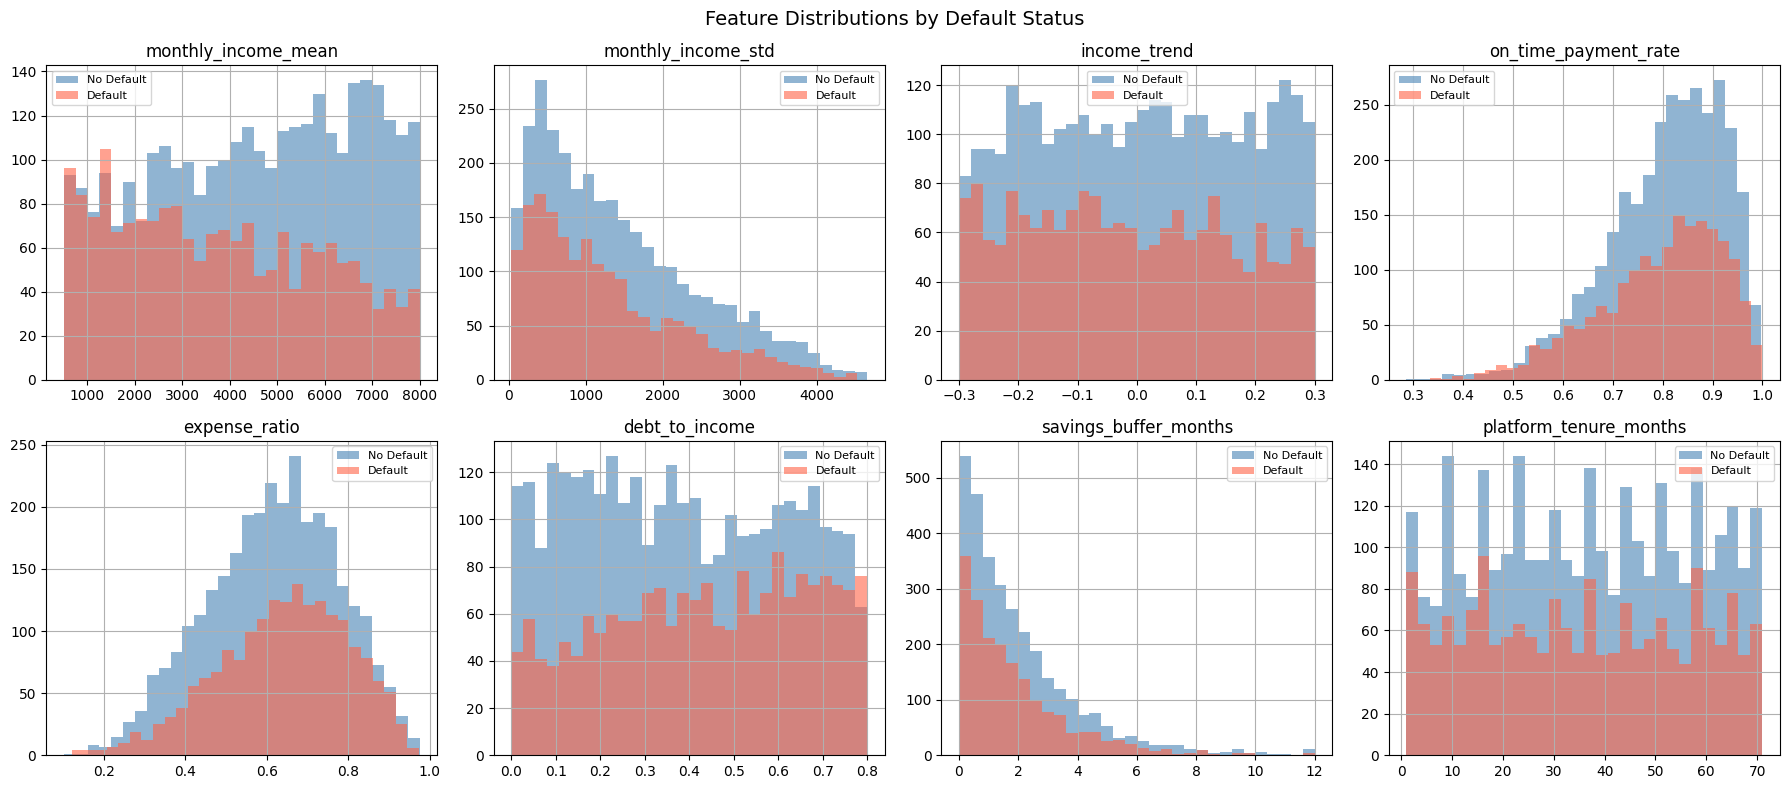


Default rate: 37.4 %

Correlation with default:
monthly_income_mean        -0.175182
monthly_income_std         -0.070673
active_platforms           -0.060097
income_trend               -0.055800
on_time_payment_rate       -0.055012
savings_buffer_months      -0.036750
platform_tenure_months     -0.027983
total_gig_history_months   -0.025351
expense_ratio               0.078177
debt_to_income              0.111606
default                     1.000000
Name: default, dtype: float64


In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.suptitle('Feature Distributions by Default Status', fontsize=14)

features = ['monthly_income_mean', 'monthly_income_std', 'income_trend',
            'on_time_payment_rate', 'expense_ratio', 'debt_to_income',
            'savings_buffer_months', 'platform_tenure_months']

for ax, feat in zip(axes.flatten(), features):
    df[df['default'] == 0][feat].hist(ax=ax, alpha=0.6, label='No Default', bins=30, color='steelblue')
    df[df['default'] == 1][feat].hist(ax=ax, alpha=0.6, label='Default', bins=30, color='tomato')
    ax.set_title(feat)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

print("\nDefault rate:", round(df['default'].mean() * 100, 2), "%")
print("\nCorrelation with default:")
print(df.corr()['default'].sort_values())

In [4]:
from sklearn.model_selection import train_test_split

# Engineer extra features
df['income_stability_score'] = df['monthly_income_mean'] / (df['monthly_income_std'] + 1)
df['platform_diversification'] = df['active_platforms'] / df['platform_tenure_months'].clip(lower=1)
df['financial_cushion'] = df['savings_buffer_months'] * (1 - df['expense_ratio'])
df['risk_composite'] = df['debt_to_income'] * df['expense_ratio'] / (df['on_time_payment_rate'] + 0.01)

FEATURES = [
    'platform_tenure_months', 'monthly_income_mean', 'monthly_income_std',
    'income_trend', 'active_platforms', 'on_time_payment_rate',
    'expense_ratio', 'debt_to_income', 'savings_buffer_months',
    'total_gig_history_months', 'income_stability_score',
    'platform_diversification', 'financial_cushion', 'risk_composite'
]

X = df[FEATURES]
y = df['default']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate in train: {y_train.mean():.2%}")

Train: (4000, 14), Test: (1000, 14)
Default rate in train: 37.40%


ROC-AUC Score : 0.6495
              precision    recall  f1-score   support

  No Default       0.68      0.80      0.74       626
     Default       0.54      0.38      0.45       374

    accuracy                           0.65      1000
   macro avg       0.61      0.59      0.59      1000
weighted avg       0.63      0.65      0.63      1000



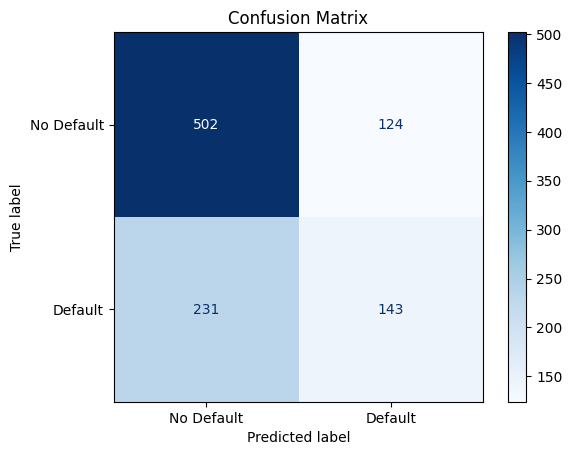

In [5]:
import lightgbm as lgb
from sklearn.metrics import (classification_report, roc_auc_score,
                              confusion_matrix, ConfusionMatrixDisplay)

model = lgb.LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    num_leaves=31,
    min_child_samples=30,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42,
    verbose=-1
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False)]
)

y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("=" * 50)
print(f"ROC-AUC Score : {roc_auc_score(y_test, y_prob):.4f}")
print("=" * 50)
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['No Default', 'Default'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

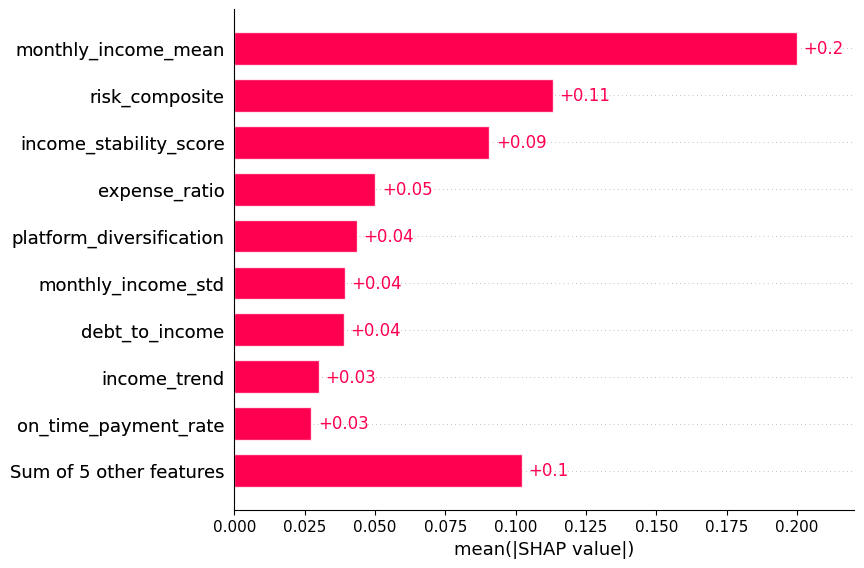

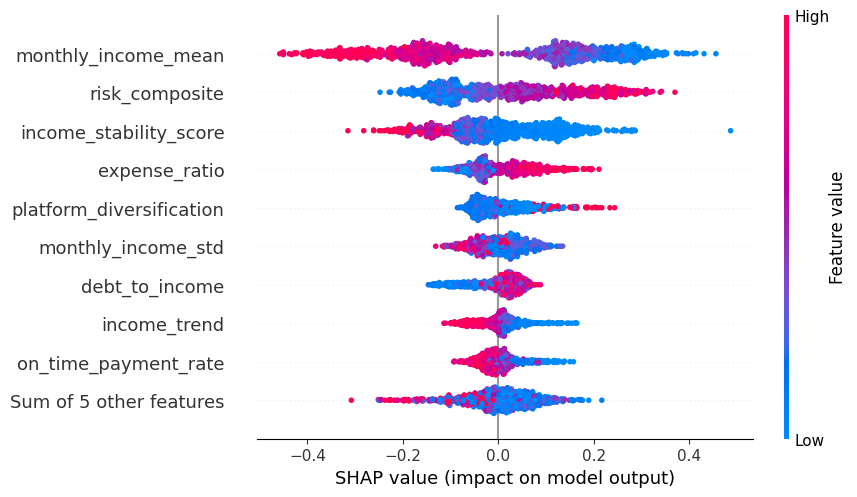

In [11]:
explainer = shap.Explainer(model, X_test)
shap_values = explainer(X_test)

# Global importance
shap.plots.bar(shap_values)

# Beeswarm
shap.plots.beeswarm(shap_values)

In [15]:
import joblib
import json

# Save model
joblib.dump(model, 'credit_model.joblib')

# Save feature list and threshold
metadata = {
    "features": FEATURES,
    "threshold": 0.4,
    "model_auc": round(roc_auc_score(y_test, y_prob), 4),
    "version": "1.0.0"
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Model saved: credit_model.joblib")
print("Metadata saved: model_metadata.json")
print(f"Model AUC: {metadata['model_auc']}")

Model saved: credit_model.joblib
Metadata saved: model_metadata.json
Model AUC: 0.6495
